In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Data Inspecting & Cleaning

**Mục tiêu:** xác nhận chất lượng dữ liệu đầu vào, chuẩn hóa kiểu dữ liệu và xử lý giá trị thiếu trước khi phân tích.

**Nội dung thực hiện:**
- Nạp dữ liệu `whoop_fitness_dataset_100k.csv` và kiểm tra kích thước tập dữ liệu.
- Chuyển cột `date` sang định dạng thời gian.
- Kiểm tra missing values và xử lý thiếu dữ liệu ở `workout_time_of_day`.
- Loại bỏ `sleep_performance` do không có tính biến thiên.

**Kết quả chính:**
- Dataset có `100,000` dòng và `39` cột ở thời điểm nạp ban đầu.
- Phát hiện `45,990` giá trị thiếu ở `workout_time_of_day` và đã được thay bằng `No Workout`.

In [2]:
current_dir = os.getcwd()
data_folder = "data"
file_name = "whoop_fitness_dataset_100k.csv"
file_path = os.path.join(current_dir, "..", data_folder, file_name)

df = pd.read_csv(file_path)

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (100000, 39)


,user_id,date,day_of_week,age,gender,weight_kg,height_cm,fitness_level,primary_sport,recovery_score,day_strain,sleep_hours,sleep_efficiency,sleep_performance,light_sleep_hours,rem_sleep_hours,deep_sleep_hours,wake_ups,time_to_fall_asleep_min,hrv,resting_heart_rate,hrv_baseline,rhr_baseline,respiratory_rate,skin_temp_deviation,calories_burned,workout_completed,activity_type,activity_duration_min,activity_strain,avg_heart_rate,max_heart_rate,activity_calories,hr_zone_1_min,hr_zone_2_min,hr_zone_3_min,hr_zone_4_min,hr_zone_5_min,workout_time_of_day
0,USER_00001,2023-01-01,Sunday,56,Female,53.9,167.2,Beginner,Weight Training,57.8,7.33,6.13,72.3,100.0,3.68,1.23,1.22,1,17.0,118.3,61.5,101,59,11.1,0.30,2849.0,0,Rest Day,0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,USER_00001,2023-01-02,Monday,56,Female,53.9,167.2,Beginner,Weight Training,62.6,10.38,6.33,78.3,100.0,3.97,1.41,0.95,1,5.8,105.7,57.5,101,59,15.9,-0.37,3201.0,1,Weight Training,62,7.47,121.2,137.6,371.0,11.9,18.0,15.9,11.6,4.6,Evening
2,USER_00001,2023-01-03,Tuesday,56,Female,53.9,167.2,Beginner,Weight Training,81.5,7.16,6.17,78.8,100.0,3.70,1.52,0.95,0,5.0,95.3,56.7,101,59,14.9,-0.67,2697.0,0,Rest Day,0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,USER_00001,2023-01-04,Wednesday,56,Female,53.9,167.2,Beginner,Weight Training,55.0,16.47,6.49,80.3,100.0,3.94,1.55,1.00,0,5.0,76.2,60.8,101,59,16.7,0.49,4175.0,0,Rest Day,0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,USER_00001,2023-01-05,Thursday,56,Female,53.9,167.2,Beginner,Weight Training,62.5,16.67,6.67,73.0,100.0,4.14,1.49,1.04,0,5.0,94.4,65.6,101,59,16.7,1.69,4116.0,1,Weight Training,51,15.27,136.4,152.8,623.0,3.7,6.0,13.7,18.6,9.0,Evening


In [3]:
df.describe()

,age,weight_kg,height_cm,recovery_score,day_strain,sleep_hours,sleep_efficiency,sleep_performance,light_sleep_hours,rem_sleep_hours,deep_sleep_hours,wake_ups,time_to_fall_asleep_min,hrv,resting_heart_rate,hrv_baseline,rhr_baseline,respiratory_rate,skin_temp_deviation,calories_burned,workout_completed,activity_duration_min,activity_strain,avg_heart_rate,max_heart_rate,activity_calories,hr_zone_1_min,hr_zone_2_min,hr_zone_3_min,hr_zone_4_min,hr_zone_5_min
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.642950,72.707693,171.754403,65.130442,9.911999,7.296272,82.883422,100.0,4.378101,1.641338,1.276817,0.338920,5.577995,73.235746,57.627420,73.356860,59.163250,15.993832,0.003286,3286.646650,0.540100,27.646820,5.740622,74.555414,84.158187,241.158940,4.492818,6.772501,7.270141,6.550316,2.607983
std,13.257307,13.896367,9.337338,17.698584,4.489623,0.972416,10.222554,0.0,0.603068,0.242734,0.200364,0.618803,2.183646,28.477633,9.268706,25.040026,8.392176,2.002110,0.500186,702.036628,0.498392,29.018375,6.442949,69.630320,78.495935,299.910276,6.081894,7.527003,8.371101,8.492293,3.829844
min,18.000000,38.100000,149.400000,5.000000,0.000000,4.000000,50.000000,100.0,2.240000,0.810000,0.600000,0.000000,5.000000,20.000000,40.000000,30.000000,45.000000,7.500000,-2.390000,871.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,62.900000,165.300000,52.400000,6.650000,6.650000,76.500000,100.0,3.980000,1.480000,1.140000,0.000000,5.000000,51.500000,50.300000,54.000000,52.000000,14.600000,-0.340000,2784.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,41.000000,72.100000,171.500000,64.500000,9.530000,7.460000,85.000000,100.0,4.460000,1.660000,1.280000,0.000000,5.000000,72.600000,57.100000,73.000000,59.000000,16.000000,0.010000,3236.000000,1.000000,27.000000,2.830000,115.900000,132.400000,84.000000,1.400000,5.000000,5.000000,1.200000,0.000000
75%,53.000000,82.000000,178.900000,77.400000,12.890000,8.030000,90.500000,100.0,4.820000,1.820000,1.420000,1.000000,5.000000,94.500000,64.800000,93.000000,66.000000,17.300000,0.340000,3754.000000,1.000000,51.000000,11.980000,138.400000,156.200000,455.000000,7.300000,12.400000,13.600000,12.400000,4.600000
max,64.000000,115.000000,195.800000,100.000000,21.000000,10.000000,100.000000,100.0,6.210000,2.430000,1.930000,7.000000,51.300000,150.000000,85.500000,119.000000,74.000000,24.500000,2.020000,5695.000000,1.000000,119.000000,21.000000,181.800000,202.000000,1831.000000,45.500000,46.500000,42.900000,46.600000,29.500000


In [4]:
df['primary_sport'].unique()

array(['Weight Training', 'CrossFit', 'Cycling', 'Swimming', 'Walking',
       'Yoga', 'Running', 'HIIT'], dtype=object)

In [5]:
# Xử lý dữ liệu thời gian
df['date'] = pd.to_datetime(df['date'])

# Kiểm tra và xử lý giá trị thiếu
print("\n--- Missing Values ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Điền 'Unknown' cho workout_time_of_day nếu bị thiếu (nghĩa là không tập)
df['workout_time_of_day'] = df['workout_time_of_day'].fillna('No Workout')

# Drop sleep_performance do không có variance
df.drop(columns=['sleep_performance'], inplace=True)


--- Missing Values ---
workout_time_of_day    45990
dtype: int64


## 2. Data Visualizing

**Mục tiêu:** mô tả đặc trưng phân phối, quan hệ giữa các biến sinh lý và mức vận động, làm cơ sở cho bước tạo đặc trưng/mô hình.

**Nội dung trực quan hóa:**
- Phân phối `day_strain` để quan sát mức cường độ vận động phổ biến.
- Scatter `recovery_score` vs `day_strain` theo `fitness_level` để kiểm tra xu hướng tải tập theo trạng thái phục hồi.
- Heatmap tương quan nhóm biến trọng tâm (`day_strain`, `recovery_score`, `sleep_hours`, `hrv`, `resting_heart_rate`, `wake_ups`, `age`).

**Nhận định:**
- Cấu trúc dữ liệu thể hiện rõ tính đa biến và phù hợp cho cả bài toán phân loại lẫn dự báo chuỗi thời gian.

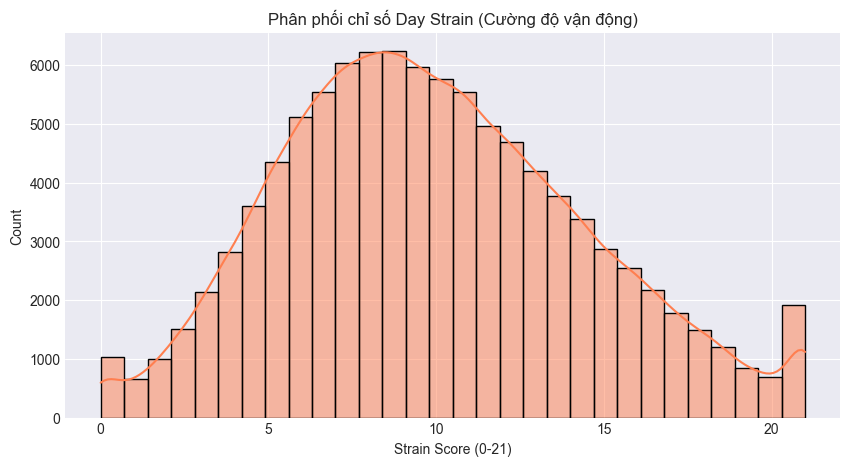

In [6]:
# Xem phân phối của Day Strain (Thang điểm 0-21)
plt.figure(figsize=(10, 5))
sns.histplot(df['day_strain'], bins=30, kde=True, color='coral')
plt.title('Phân phối chỉ số Day Strain (Cường độ vận động)')
plt.xlabel('Strain Score (0-21)')
plt.show()

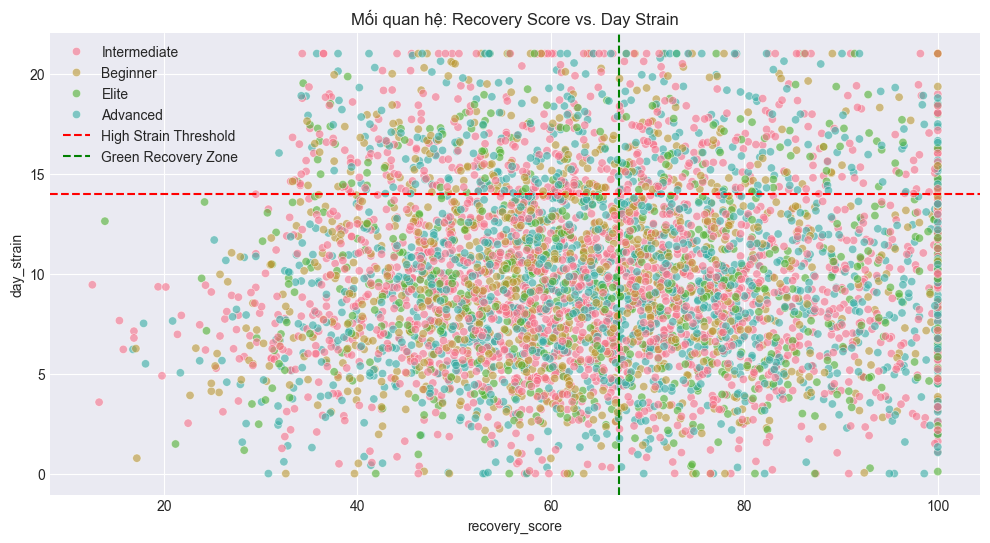

In [7]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df.sample(5000, random_state=42), 
                x='recovery_score', 
                y='day_strain', 
                hue='fitness_level', 
                alpha=0.6)

plt.axhline(y=14, color='red', linestyle='--', label='High Strain Threshold')
plt.axvline(x=67, color='green', linestyle='--', label='Green Recovery Zone')
plt.title('Mối quan hệ: Recovery Score vs. Day Strain')
plt.legend()
plt.show()

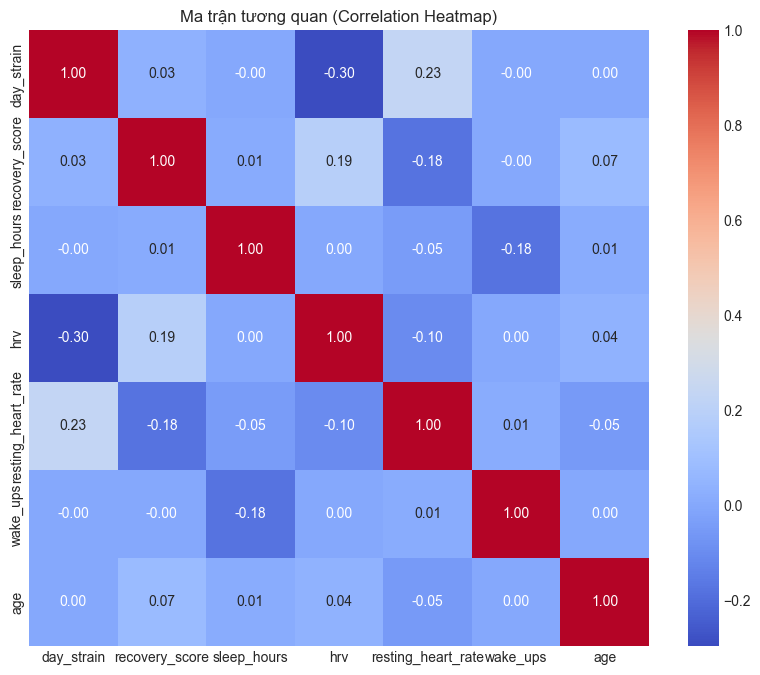

In [8]:
# Ma trận tương quan
focus_cols = ['day_strain', 'recovery_score', 'sleep_hours', 'hrv', 
              'resting_heart_rate', 'wake_ups', 'age']

plt.figure(figsize=(10, 8))
sns.heatmap(df[focus_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận tương quan (Correlation Heatmap)')
plt.show()

## 3. Feature Engineering

**Mục tiêu:** tạo biến dẫn xuất có ý nghĩa sinh lý và thiết kế nhãn mục tiêu phục vụ huấn luyện mô hình.

**Nội dung thực hiện:**
- Tạo biến mới: `bmi`, `hrv_rhr_ratio`, `is_weekend`, `age_group`.
- Xây dựng nhãn phân loại `strain_class` thành 4 mức tải tập (`Rest/Recovery`, `Moderate`, `High`, `All Out`).
- Loại bỏ các biến rò rỉ thông tin tương lai (`day_strain` gốc, biến kết quả workout trong ngày, metadata không cần thiết).

**Kết quả chính:**
- Tập đặc trưng cuối cùng có `25` biến.
- Phân phối nhãn mất cân bằng: lớp 0 = `53.899%`, lớp 1 = `27.210%`, lớp 2 = `13.820%`, lớp 3 = `5.071%` (cần lưu ý khi đánh giá mô hình).

In [9]:
# Chỉ số BMI (Body Mass Index)
df['bmi'] = df['weight_kg'] / ((df['height_cm'] / 100) ** 2)

# Tỷ lệ HRV so với nhịp tim nghỉ (Cân bằng hệ thần kinh)
df['hrv_rhr_ratio'] = df['hrv'] / df['resting_heart_rate']

# Thông tin ngày tháng (Cuối tuần thường tập khác ngày thường)
df['is_weekend'] = df['date'].dt.dayofweek.isin([5, 6]).astype(int)

# Phân nhóm tuổi
bins = [18, 30, 45, 60, 100]
labels = ['Young', 'Adult', 'Middle-Aged', 'Senior']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

print("Đã tạo xong các đặc trưng mới: bmi, hrv_rhr_ratio, is_weekend, age_group.")

Đã tạo xong các đặc trưng mới: bmi, hrv_rhr_ratio, is_weekend, age_group.


In [10]:
def categorize_strain(strain):
    if strain < 10:
        return 0 # Rest/Active Recovery (Nghỉ ngơi/Tập nhẹ)
    elif strain < 14:
        return 1 # Moderate (Trung bình)
    elif strain < 18:
        return 2 # High (Cao)
    else:
        return 3 # All Out (Tối đa)

# Tạo cột Label
df['strain_class'] = df['day_strain'].apply(categorize_strain)

# Kiểm tra sự cân bằng của các lớp
print("\nPhân phối các lớp bài tập:")
print(df['strain_class'].value_counts(normalize=True))

# Map tên để dễ hiểu (chỉ dùng để in ra)
class_names = {0: 'Rest/Recovery', 1: 'Moderate', 2: 'High', 3: 'All Out'}


Phân phối các lớp bài tập:
strain_class
0    0.53899
1    0.27210
2    0.13820
3    0.05071
Name: proportion, dtype: float64


In [11]:
# Danh sách các cột CẦN LOẠI BỎ (Future Data / Leakage)
leakage_cols = [
    # Biến mục tiêu gốc và các biến liên quan
    'day_strain', 'min_strain', 'max_strain', 
    
    # Kết quả của buổi tập (chưa biết vào buổi sáng)
    'calories_burned', 'activity_calories', 'activity_strain',
    'avg_heart_rate', 'max_heart_rate', 'workout_completed',
    'activity_duration_min', 'hr_zone_1_min', 'hr_zone_2_min',
    'hr_zone_3_min', 'hr_zone_4_min', 'hr_zone_5_min',
    'workout_time_of_day', 'activity_type', 
    
    # Metadata không dùng để training
    'user_id', 'date'
]

# Chỉ giữ lại các cột có trong DataFrame hiện tại
cols_to_drop = [c for c in leakage_cols if c in df.columns]

# Tạo tập X (Features) và y (Label)
X = df.drop(columns=cols_to_drop + ['strain_class']) # Xóa cả Label khỏi X
y = df['strain_class']

print(f"Final Features (X) columns ({len(X.columns)}):")
print(X.columns.tolist())

Final Features (X) columns (25):
['day_of_week', 'age', 'gender', 'weight_kg', 'height_cm', 'fitness_level', 'primary_sport', 'recovery_score', 'sleep_hours', 'sleep_efficiency', 'light_sleep_hours', 'rem_sleep_hours', 'deep_sleep_hours', 'wake_ups', 'time_to_fall_asleep_min', 'hrv', 'resting_heart_rate', 'hrv_baseline', 'rhr_baseline', 'respiratory_rate', 'skin_temp_deviation', 'bmi', 'hrv_rhr_ratio', 'is_weekend', 'age_group']


## 4. Huấn luyện mô hình (Bài toán phân loại thống nhất)

**Mục tiêu:** thống nhất toàn bộ bài toán theo hướng **phân loại cường độ tập** (`strain_class`) cho cả:
- **Học máy truyền thống:** XGBoost.
- **Học sâu theo chuỗi thời gian:** GRU from scratch.

**Lưu ý tổ chức chương:**
- Chương 4 chỉ tập trung vào **chuẩn bị và huấn luyện** mô hình.
- Toàn bộ phần **đánh giá** sẽ được tách riêng và hợp nhất trong **Chương 5**.

### 4.1. Chuẩn bị dữ liệu cho huấn luyện (Train/Test Split + Preprocessing)

**Nhiệm vụ của cell:**
- Tách dữ liệu thành `X_train`, `X_test`, `y_train`, `y_test` với `stratify=y`.
- Xác định nhóm biến số và biến phân loại.
- Tạo `ColumnTransformer` để chuẩn hóa biến số (`StandardScaler`) và mã hóa biến phân loại (`OneHotEncoder`).

**Nhận xét kết quả:**
- Hệ thống nhận diện được **20 biến số** và **5 biến phân loại**.
- Pipeline tiền xử lý đã sẵn sàng để đưa vào mô hình học máy ở bước tiếp theo.

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline # Quan trọng để dùng SMOTE trong pipeline
from imblearn.over_sampling import SMOTE

# 1. Tách Feature và Target
# Đảm bảo y là số (0, 1, 2, 3) đã làm ở bước trước
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Định nghĩa Pipeline xử lý dữ liệu (Preprocessing)
# Tự động lấy cột số và cột phân loại
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

# Tạo transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

print("--- Data Split & Preprocessor Ready ---")

Numeric features: 20
Categorical features: 5
--- Data Split & Preprocessor Ready ---


### 4.2. Huấn luyện mô hình học máy XGBoost (phân loại)

**Nhiệm vụ của cell:**
- Khởi tạo mô hình `XGBClassifier` và ghép với `preprocessor` thành pipeline huấn luyện.
- Huấn luyện mô hình trên tập train.
- Tạo dự đoán trên tập test để sử dụng cho **Chương 5 - Đánh giá chung**.

**Lưu ý:**
- Không đánh giá riêng tại đây để tránh phân tán kết quả.
- Các chỉ số (`F1-Macro`, `Accuracy`, `classification_report`) sẽ được báo cáo tập trung ở Chương 5.

In [13]:
from xgboost import XGBClassifier
import time

# Khởi tạo mô hình XGBoost cho bài toán phân loại đa lớp strain_class
xgb_model = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42
)

# Tạo pipeline: Preprocessing -> XGBoost
xgb_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb_model)
])

# Huấn luyện
print("Đang huấn luyện mô hình XGBoost...")
start_time = time.time()
xgb_pipeline.fit(X_train, y_train)
train_time_xgb = time.time() - start_time
print(f"Hoàn thành trong {train_time_xgb:.2f}s")

# Tạo dự đoán để dùng ở Chương 5
y_pred_xgb = xgb_pipeline.predict(X_test)
print("Đã tạo dự đoán XGBoost cho tập test. Chuyển sang Chương 5 để đánh giá chung.")

Đang huấn luyện mô hình XGBoost...
Hoàn thành trong 1.37s
Đã tạo dự đoán XGBoost cho tập test. Chuyển sang Chương 5 để đánh giá chung.


### 4.3. Huấn luyện mô hình học sâu GRU from scratch cho phân loại chuỗi thời gian

**Bài toán:** sử dụng `lookback=14` ngày lịch sử để dự đoán lớp `strain_class` tại ngày kế tiếp.

**Cấu hình dữ liệu chuỗi:**
- Mỗi mẫu đầu vào có dạng `(14, 5)` với 5 biến: `recovery_score`, `sleep_hours`, `hrv`, `resting_heart_rate`, `day_strain`.
- Nhãn đầu ra là lớp `strain_class` tại thời điểm kế tiếp.
- Chia tập theo thời gian: Train 70%, Validation 15%, Test 15%.

**Phạm vi triển khai:**
- Chỉ dùng **GRU** cho nhánh học sâu (đã loại bỏ LSTM).
- GRU được xây dựng **from scratch** bằng cách tự cài đặt phương trình cổng, không dùng lớp `GRU` dựng sẵn.
- Chương 4 chỉ huấn luyện và sinh dự đoán; đánh giá tổng hợp đặt ở Chương 5.

In [14]:
# ===============================
# 4.3.1 Chuẩn bị dữ liệu chuỗi cho GRU from scratch
# ===============================
import numpy as np
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

# 1) Chuẩn bị dữ liệu chuỗi thời gian
ts_df = df[['user_id', 'date', 'recovery_score', 'sleep_hours', 'hrv', 'resting_heart_rate', 'day_strain', 'strain_class']].copy()
ts_df = ts_df.sort_values(['user_id', 'date']).reset_index(drop=True)
ts_df['strain_class'] = ts_df['strain_class'].astype(int)

feature_cols = ['recovery_score', 'sleep_hours', 'hrv', 'resting_heart_rate', 'day_strain']
lookback = 14

X_seq, y_seq = [], []
for _, g in ts_df.groupby('user_id'):
    values = g[feature_cols].values
    class_values = g['strain_class'].values

    if len(g) < lookback + 1:
        continue

    for i in range(len(g) - lookback):
        X_seq.append(values[i:i+lookback])
        y_seq.append(class_values[i+lookback])

X_seq = np.array(X_seq, dtype=np.float32)
y_seq = np.array(y_seq, dtype=np.int32)

print(f"X_seq shape: {X_seq.shape}")
print(f"y_seq shape: {y_seq.shape}")

# 2) Chia train/val/test theo thời gian
y_seq_labels = y_seq.copy()
num_classes = len(np.unique(y_seq_labels))

n_samples = len(X_seq)
train_end = int(n_samples * 0.7)
val_end = int(n_samples * 0.85)

X_train_seq, X_val_seq, X_test_seq = X_seq[:train_end], X_seq[train_end:val_end], X_seq[val_end:]
y_train_seq_labels = y_seq_labels[:train_end]
y_val_seq_labels = y_seq_labels[train_end:val_end]
y_test_seq_labels = y_seq_labels[val_end:]

print(f"Train: {X_train_seq.shape[0]}, Val: {X_val_seq.shape[0]}, Test: {X_test_seq.shape[0]}")
print(f"Số lớp phân loại: {num_classes}")

# 3) Scale dữ liệu đầu vào
n_features = X_train_seq.shape[-1]
feature_scaler = MinMaxScaler()

X_train_2d = X_train_seq.reshape(-1, n_features)
X_val_2d = X_val_seq.reshape(-1, n_features)
X_test_2d = X_test_seq.reshape(-1, n_features)

X_train_scaled = feature_scaler.fit_transform(X_train_2d).reshape(X_train_seq.shape)
X_val_scaled = feature_scaler.transform(X_val_2d).reshape(X_val_seq.shape)
X_test_scaled = feature_scaler.transform(X_test_2d).reshape(X_test_seq.shape)

# One-hot nhãn cho huấn luyện deep learning
y_train_seq = to_categorical(y_train_seq_labels, num_classes=num_classes)
y_val_seq = to_categorical(y_val_seq_labels, num_classes=num_classes)
y_test_seq = to_categorical(y_test_seq_labels, num_classes=num_classes)

print("Dữ liệu đã sẵn sàng cho GRU from scratch.")

X_seq shape: (95996, 14, 5)
y_seq shape: (95996,)
Train: 67197, Val: 14399, Test: 14400
Số lớp phân loại: 4
Dữ liệu đã sẵn sàng cho GRU from scratch.


### 4.3.2. Xây dựng và huấn luyện GRU from scratch

**Kiến trúc GRU tự cài đặt:**
- Ở mỗi thời điểm `t`, với đầu vào `x_t` và trạng thái ẩn trước đó `h_{t-1}`:
  - Cổng cập nhật: `z_t = sigmoid(x_t W_z + h_{t-1} U_z + b_z)`
  - Cổng đặt lại: `r_t = sigmoid(x_t W_r + h_{t-1} U_r + b_r)`
  - Trạng thái ứng viên: `h~_t = tanh(x_t W_h + (r_t * h_{t-1}) U_h + b_h)`
  - Trạng thái mới: `h_t = (1 - z_t) * h_{t-1} + z_t * h~_t`
- Sau khi quét hết chuỗi, lấy `h_T` đưa qua tầng phân loại `Dense(softmax)`.

**Từ khóa from scratch:**
- Không dùng `tensorflow.keras.layers.GRU`.
- Tự khai báo toàn bộ trọng số `W/U/b` và tự viết vòng lặp thời gian để cập nhật trạng thái ẩn.

In [16]:
# ===============================
# 4.3.2 Xây dựng và huấn luyện GRU from scratch (phân loại)
# ===============================

class CustomGRUCell(tf.keras.layers.Layer):
    def __init__(self, units):
        super().__init__()
        self.units = units

    def build(self, input_shape):
        input_dim = input_shape[-1]

        self.W_z = self.add_weight(shape=(input_dim, self.units), initializer='glorot_uniform', trainable=True)
        self.U_z = self.add_weight(shape=(self.units, self.units), initializer='orthogonal', trainable=True)
        self.b_z = self.add_weight(shape=(self.units,), initializer='zeros', trainable=True)

        self.W_r = self.add_weight(shape=(input_dim, self.units), initializer='glorot_uniform', trainable=True)
        self.U_r = self.add_weight(shape=(self.units, self.units), initializer='orthogonal', trainable=True)
        self.b_r = self.add_weight(shape=(self.units,), initializer='zeros', trainable=True)

        self.W_h = self.add_weight(shape=(input_dim, self.units), initializer='glorot_uniform', trainable=True)
        self.U_h = self.add_weight(shape=(self.units, self.units), initializer='orthogonal', trainable=True)
        self.b_h = self.add_weight(shape=(self.units,), initializer='zeros', trainable=True)

    def call(self, x_t, h_prev):
        z_t = tf.sigmoid(tf.matmul(x_t, self.W_z) + tf.matmul(h_prev, self.U_z) + self.b_z)
        r_t = tf.sigmoid(tf.matmul(x_t, self.W_r) + tf.matmul(h_prev, self.U_r) + self.b_r)
        h_tilde = tf.tanh(tf.matmul(x_t, self.W_h) + tf.matmul(r_t * h_prev, self.U_h) + self.b_h)
        h_t = (1.0 - z_t) * h_prev + z_t * h_tilde
        return h_t


class StackedGRUClassifier(tf.keras.Model):
    def __init__(self, units_1, units_2, num_classes, dropout_rate=0.2):
        super().__init__()
        self.gru_cell_1 = CustomGRUCell(units_1)
        self.gru_cell_2 = CustomGRUCell(units_2)
        self.dropout = tf.keras.layers.Dropout(dropout_rate)
        self.classifier = tf.keras.layers.Dense(num_classes, activation='softmax')

    def call(self, inputs, training=False):
        batch_size = tf.shape(inputs)[0]

        h1 = tf.zeros((batch_size, self.gru_cell_1.units), dtype=inputs.dtype)
        h2 = tf.zeros((batch_size, self.gru_cell_2.units), dtype=inputs.dtype)

        # Dùng unstack theo trục thời gian để tương thích Graph mode (tránh iterate symbolic tensor)
        time_slices = tf.unstack(inputs, axis=1)
        for x_t in time_slices:
            h1 = self.gru_cell_1(x_t, h1)
            h1_drop = self.dropout(h1, training=training)
            h2 = self.gru_cell_2(h1_drop, h2)

        h2 = self.dropout(h2, training=training)
        logits = self.classifier(h2)
        return logits


gru_model = StackedGRUClassifier(units_1=64, units_2=32, num_classes=num_classes, dropout_rate=0.2)
gru_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\nĐang huấn luyện GRU from scratch...")
history_gru = gru_model.fit(
    X_train_scaled, y_train_seq,
    validation_data=(X_val_scaled, y_val_seq),
    epochs=20,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

# Tạo dự đoán để dùng ở Chương 5
y_proba_gru = gru_model.predict(X_test_scaled, verbose=0)
y_pred_gru = np.argmax(y_proba_gru, axis=1)
print("Đã huấn luyện GRU from scratch và tạo dự đoán cho tập test. Đánh giá ở Chương 5.")


Đang huấn luyện GRU from scratch...
Epoch 1/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5348 - loss: 1.0850 - val_accuracy: 0.5421 - val_loss: 1.0420
Epoch 2/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5355 - loss: 1.0481 - val_accuracy: 0.5427 - val_loss: 1.0390
Epoch 3/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5363 - loss: 1.0435 - val_accuracy: 0.5424 - val_loss: 1.0377
Epoch 4/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5362 - loss: 1.0408 - val_accuracy: 0.5416 - val_loss: 1.0355
Epoch 5/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5363 - loss: 1.0399 - val_accuracy: 0.5418 - val_loss: 1.0347
Epoch 6/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5372 - loss: 1.0386 - val_accuracy: 0.5418 - val_loss: 1.0339
Epoch 7/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5372 - loss: 1.0372 - val_accuracy: 0.5418 - val_loss: 1.0333
Epoch 8/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.

## 5. Đánh giá chung mô hình phân loại

**Mục tiêu chương 5:**
- Tổng hợp đánh giá mô hình học máy và học sâu trong cùng một nơi.
- So sánh công bằng theo các chỉ số chính cho bài toán phân loại đa lớp `strain_class`.

**Chỉ số sử dụng:**
- `F1-Macro`
- `Accuracy`
- `classification_report`

In [17]:
from sklearn.metrics import classification_report, f1_score, accuracy_score
import pandas as pd
import numpy as np

class_name_map = {
    0: 'Rest',
    1: 'Moderate',
    2: 'High',
    3: 'All Out'
}


def evaluate_classification_model(model_name, y_true, y_pred):
    labels = np.unique(np.concatenate([y_true, y_pred]))
    target_names = [class_name_map.get(int(lbl), f'Class {int(lbl)}') for lbl in labels]

    f1 = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)

    print(f"\n{model_name}")
    print("-" * 50)
    print(f"F1-Macro: {f1:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_true, y_pred, labels=labels, target_names=target_names))

    return {
        'Model': model_name,
        'F1-Macro': round(f1, 4),
        'Accuracy': round(acc, 4)
    }


results = []

# 1) Đánh giá XGBoost (học máy truyền thống)
results.append(evaluate_classification_model('XGBoost', y_test.to_numpy(), y_pred_xgb))

# 2) Đánh giá GRU from scratch (học sâu)
results.append(evaluate_classification_model('GRU-from-scratch', y_test_seq_labels, y_pred_gru))

summary_df = pd.DataFrame(results).sort_values(by='F1-Macro', ascending=False).reset_index(drop=True)

print("\nBẢNG TỔNG HỢP KẾT QUẢ")
print("-" * 50)
print(summary_df)

best_model_name = summary_df.loc[0, 'Model']
print(f"\nMô hình tốt nhất theo F1-Macro: {best_model_name}")


XGBoost
--------------------------------------------------
F1-Macro: 0.5208
Accuracy: 0.6528
Classification Report:
              precision    recall  f1-score   support

        Rest       0.79      0.86      0.82     10780
    Moderate       0.46      0.46      0.46      5442
        High       0.43      0.34      0.38      2764
     All Out       0.55      0.34      0.42      1014

    accuracy                           0.65     20000
   macro avg       0.56      0.50      0.52     20000
weighted avg       0.64      0.65      0.64     20000


GRU-from-scratch
--------------------------------------------------
F1-Macro: 0.1759
Accuracy: 0.5408
Classification Report:
              precision    recall  f1-score   support

        Rest       0.54      1.00      0.70      7789
    Moderate       0.30      0.00      0.00      3940
        High       0.00      0.00      0.00      1935
     All Out       0.00      0.00      0.00       736

    accuracy                           0.54     14